# Forecasting Blog Engagement with Machine Learning: From Linear Regression to Gradient Boosting

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA 

from scipy import stats
from scipy.stats import kruskal

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

## Data Loading
Load the training and testing datasets from multiple CSV files and merge them into unified datasets using `blog_id`.

In [2]:
path_data = r'C:\Users\wlgus\OneDrive\바탕 화면\Blog_Content\Data'

df_train_comment = pd.read_csv(path_data + '/' + 'df_train_comment.csv')
df_train_comment.head(5)

,blog_id,total_comment_before_basetime_page,24h_comment_before_basetime_page,difference_total_24h_comment_page,24h_comment_after_blogpost_page,difference_24h_comment_between_basetime_blogpost_page,avg(total_comment_before_basetime_blog),std(total_comment_before_basetime_blog),min(total_comment_before_basetime_blog),max(total_comment_before_basetime_blog),...,avg(24h_comment_after_blogpost_blog),std(24h_comment_after_blogpost_blog),min(24h_comment_after_blogpost_blog),max(24h_comment_after_blogpost_blog),median(24h_comment_after_blogpost_blog),avg(difference_24h_comment_between_basetime_blogpost_blog),std(difference_24h_comment_between_basetime_blogpost_blog),min(difference_24h_comment_between_basetime_blogpost_blog),max(difference_24h_comment_between_basetime_blogpost_blog),median(difference_24h_comment_between_basetime_blogpost_blog)
0,7638683741439,2.0,2.0,0.0,2.0,2.0,40.30467,53.845657,0.0,401.0,...,34.567566,48.475178,0.0,378.0,12.0,1.479934,46.18691,-356.0,377.0,0.0
1,155122932624,6.0,2.0,4.0,5.0,-2.0,40.30467,53.845657,0.0,401.0,...,34.567566,48.475178,0.0,378.0,12.0,1.479934,46.18691,-356.0,377.0,0.0
2,3017770344577,6.0,2.0,4.0,5.0,-2.0,40.30467,53.845657,0.0,401.0,...,34.567566,48.475178,0.0,378.0,12.0,1.479934,46.18691,-356.0,377.0,0.0
3,8531508743621,2.0,2.0,0.0,2.0,2.0,40.30467,53.845657,0.0,401.0,...,34.567566,48.475178,0.0,378.0,12.0,1.479934,46.18691,-356.0,377.0,0.0
4,359127110474,3.0,1.0,2.0,2.0,-1.0,40.30467,53.845657,0.0,401.0,...,34.567566,48.475178,0.0,378.0,12.0,1.479934,46.18691,-356.0,377.0,0.0


In [3]:
# Load Train Data Set
df_train_link = pd.read_csv(path_data + '/df_train_link.csv')
df_train_blog_content = pd.read_csv(path_data +'/df_train_blog_content.csv')
df_train_blog_date = pd.read_csv(path_data + '/df_train_blog_date.csv')
df_train_blog_parent = pd.read_csv(path_data + '/df_train_blog_parent.csv')
df_train_blog_target = pd.read_csv(path_data + '/df_train_blog_target.csv')

In [4]:
# Load Test Data Set
df_test_comment = pd.read_csv(path_data + '/df_test_comment.csv')
df_test_link = pd.read_csv(path_data + '/df_test_link.csv')
df_test_blog_content = pd.read_csv(path_data + '/df_test_blog_content.csv')
df_test_blog_date = pd.read_csv(path_data + '/df_test_blog_date.csv')
df_test_blog_parent = pd.read_csv(path_data + '/df_test_blog_parent.csv')
df_test_blog_target = pd.read_csv(path_data + '/df_test_blog_target.csv')

In [5]:
# Merge all training datasets using blog_id.

df_train_list = [
    df_train_link,
    df_train_blog_parent,
    df_train_blog_date,
    df_train_blog_content,
    df_train_blog_target
]

# Verify that blog_id is unique before merging.
assert df_train_comment["blog_id"].is_unique

for df_candidate in df_train_list:
    assert df_candidate["blog_id"].is_unique

df_train = df_train_comment.copy()

for df_candidate in df_train_list:
    df_train = pd.merge(
        df_train,
        df_candidate,
        on="blog_id",
        how="left"
    )

print(f"Training dataset shape: {df_train.shape}")

df_train.head()

Training dataset shape: (52397, 279)


,blog_id,total_comment_before_basetime_page,24h_comment_before_basetime_page,difference_total_24h_comment_page,24h_comment_after_blogpost_page,difference_24h_comment_between_basetime_blogpost_page,avg(total_comment_before_basetime_blog),std(total_comment_before_basetime_blog),min(total_comment_before_basetime_blog),max(total_comment_before_basetime_blog),...,word_191,word_192,word_193,word_194,word_195,word_196,word_197,word_198,word_199,target
0,7638683741439,2.0,2.0,0.0,2.0,2.0,40.30467,53.845657,0.0,401.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,155122932624,6.0,2.0,4.0,5.0,-2.0,40.30467,53.845657,0.0,401.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3017770344577,6.0,2.0,4.0,5.0,-2.0,40.30467,53.845657,0.0,401.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8531508743621,2.0,2.0,0.0,2.0,2.0,40.30467,53.845657,0.0,401.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,359127110474,3.0,1.0,2.0,2.0,-1.0,40.30467,53.845657,0.0,401.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.0


In [6]:
# Merge all testing datasets using blog_id.

df_test = df_test_comment.copy()

df_test_list = [
    df_test_link,
    df_test_blog_parent,
    df_test_blog_date,
    df_test_blog_content,
    df_test_blog_target
]

# Verify that blog_id is unique before merging.
assert df_test_comment["blog_id"].is_unique

for df_candidate in df_test_list:
    assert df_candidate["blog_id"].is_unique

for df_candidate in df_test_list:
    df_test = pd.merge(
        df_test,
        df_candidate,
        on="blog_id",
        how="left"
    )

print(f"Testing dataset shape: {df_test.shape}")

df_test.head()

Testing dataset shape: (7624, 279)


,blog_id,total_comment_before_basetime_page,24h_comment_before_basetime_page,difference_total_24h_comment_page,24h_comment_after_blogpost_page,difference_24h_comment_between_basetime_blogpost_page,avg(total_comment_before_basetime_blog),std(total_comment_before_basetime_blog),min(total_comment_before_basetime_blog),max(total_comment_before_basetime_blog),...,word_191,word_192,word_193,word_194,word_195,word_196,word_197,word_198,word_199,target
0,5610306109,35.0,35.0,0.0,35.0,35.0,10.630660,17.882992,1.0,259.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
1,1984909392749,21.0,0.0,2.0,21.0,-2.0,43.435825,75.590485,0.0,634.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,117839817913,2.0,2.0,0.0,2.0,2.0,1.733333,3.043390,0.0,9.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1453294624507,3.0,3.0,0.0,3.0,3.0,27.230215,45.970950,0.0,371.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
4,1357160498521,0.0,0.0,0.0,0.0,0.0,4.500000,6.677075,0.0,18.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Duplicate Data Check

In [7]:
# Check duplicate records excluding the unique identifier.
train_duplicates = df_train.drop(columns="blog_id").duplicated().sum()

print(f"Number of duplicate records in the training data: {train_duplicates}")

Number of duplicate records in the training data: 3309


In [8]:
# Remove duplicate records and reset the index.
before_rows = len(df_train)

df_train = (
    df_train
    .drop(columns="blog_id")
    .drop_duplicates(ignore_index=True)
)

after_rows = len(df_train)

print(f"Removed {before_rows - after_rows} duplicate records.")

Removed 3309 duplicate records.


**Observation**

A total of 3,309 duplicate records were identified after excluding the unique identifier (`blog_id`). These records were removed to reduce repeated observations in the training data and prevent duplicated samples from influencing model training.

In [9]:
df_train.head()

,total_comment_before_basetime_page,24h_comment_before_basetime_page,difference_total_24h_comment_page,24h_comment_after_blogpost_page,difference_24h_comment_between_basetime_blogpost_page,avg(total_comment_before_basetime_blog),std(total_comment_before_basetime_blog),min(total_comment_before_basetime_blog),max(total_comment_before_basetime_blog),median(total_comment_before_basetime_blog),...,word_191,word_192,word_193,word_194,word_195,word_196,word_197,word_198,word_199,target
0,2.0,2.0,0.0,2.0,2.0,40.30467,53.845657,0.0,401.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,6.0,2.0,4.0,5.0,-2.0,40.30467,53.845657,0.0,401.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,2.0,0.0,2.0,2.0,40.30467,53.845657,0.0,401.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3.0,1.0,2.0,2.0,-1.0,40.30467,53.845657,0.0,401.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.0
4,6.0,0.0,2.0,5.0,-2.0,40.30467,53.845657,0.0,401.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# Check duplicate records in the testing data excluding the unique identifier.
test_duplicates = df_test.drop(columns="blog_id").duplicated().sum()

print(f"Duplicate records in the testing data: {test_duplicates}")

Duplicate records in the testing data: 790


In [11]:
# Remove duplicate records and reset the index.
before_rows = len(df_test)

df_test = (
    df_test
    .drop(columns="blog_id")
    .drop_duplicates(ignore_index=True)
)

after_rows = len(df_test)

print(f"Rows before removing duplicates: {before_rows}")
print(f"Rows after removing duplicates: {after_rows}")
print(f"Removed duplicate records: {before_rows - after_rows}")

Rows before removing duplicates: 7624
Rows after removing duplicates: 6834
Removed duplicate records: 790


**Observation**

A total of 790 duplicate records were identified in the testing data after excluding the unique identifier (`blog_id`). These records were removed to keep the preprocessing process consistent between the training and testing datasets.

## Exploratory Data Analysis (EDA)

In [12]:
# Display the overall structure of the training dataset.
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49088 entries, 0 to 49087
Columns: 278 entries, total_comment_before_basetime_page to target
dtypes: float64(278)
memory usage: 104.1 MB


In [13]:
# Display the number of rows and columns.
print(f"Dataset Shape: {df_train.shape}")

Dataset Shape: (49088, 278)


In [14]:
# Summarize data types.
df_train.dtypes.value_counts()

float64    278
Name: count, dtype: int64

### Feature Type Identification
Although all features are stored as `float64`, they do not represent the same type of information. Binary variables with values {0, 1} are treated as categorical features, while the remaining variables are considered numerical features for subsequent analysis.

In [15]:
# Identify categorical and numerical features.

categorical_columns = []
numerical_columns = []

for column in df_train.columns:
    unique_values = df_train[column].dropna().unique()

    if len(unique_values) == 2 and set(unique_values) == {0, 1}:
        categorical_columns.append(column)
    else:
        numerical_columns.append(column)

print(f"Number of categorical features: {len(categorical_columns)}")
print(f"Number of numerical features: {len(numerical_columns)}")

Number of categorical features: 214
Number of numerical features: 64


### Missing Value Analysis
Identify missing values in the training dataset and summarize the affected features before determining an appropriate imputation strategy.

In [16]:
# Check the number of missing values in each feature.
missing_values = (
    df_train
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values[missing_values > 0]

min(comment_on_parent_blog)          22552
std(24h_link_after_blogpost_blog)      124
dtype: int64

In [17]:
# Display only features containing missing values.
missing_features = missing_values[missing_values > 0]

print("Features with missing values:")
display(missing_features)

Features with missing values:


min(comment_on_parent_blog)          22552
std(24h_link_after_blogpost_blog)      124
dtype: int64

In [18]:
# Examine the data types of features containing missing values.
df_train[missing_features.index].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49088 entries, 0 to 49087
Data columns (total 2 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   min(comment_on_parent_blog)        26536 non-null  float64
 1   std(24h_link_after_blogpost_blog)  48964 non-null  float64
dtypes: float64(2)
memory usage: 767.1 KB


**Observation**

Only two features contain missing values:

- `min(comment_on_parent_blog)` has **22,552** missing values.
- `std(24h_link_after_blogpost_blog)` has **124** missing values.

All other features are complete. The missing-value handling strategy will be determined during the data preprocessing stage.

### Target Variable Analysis
Analyze the distribution and summary statistics of the target variable to understand its characteristics before model development.

In [19]:
# Display summary statistics of the target variable.
df_train["target"].describe()

count    49088.000000
mean         6.969667
std         38.756549
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max       1424.000000
Name: target, dtype: float64

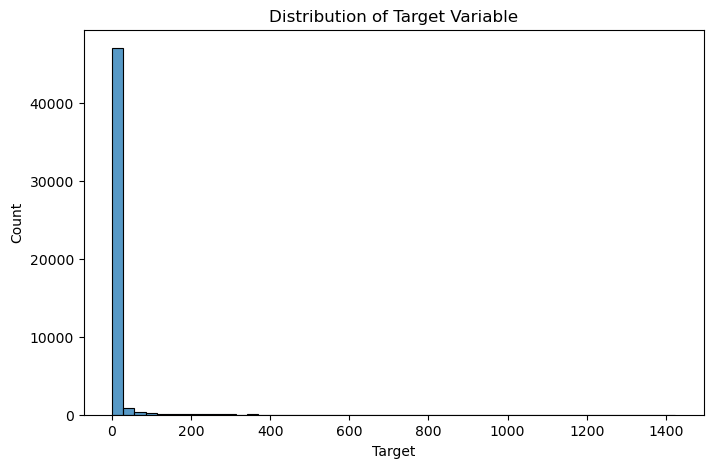

In [20]:
# Visualize the distribution of the target variable.
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_train,
    x="target",
    bins=50
)

plt.title("Distribution of Target Variable")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

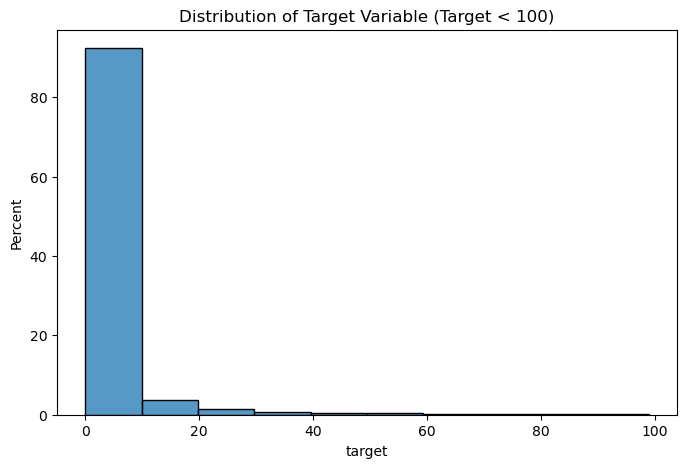

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_train[df_train["target"] < 100],
    x="target",
    binwidth=10,
    stat="percent"
)

plt.title("Distribution of Target Variable (Target < 100)")
plt.show()

In [22]:
# Percentage of observations with target values less than or equal to 10.
percentage = (
    (df_train["target"] <= 10).mean() * 100
)

print(f"Posts with 10 or fewer comments: {percentage:.1f}%")

Posts with 10 or fewer comments: 91.5%


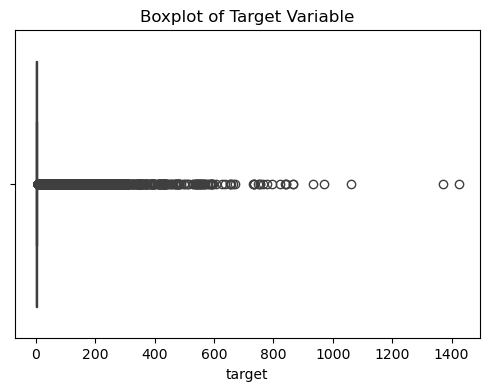

In [23]:
# Identify potential outliers in the target variable.
plt.figure(figsize=(6, 4))

sns.boxplot(
    x=df_train["target"]
)

plt.title("Boxplot of Target Variable")

plt.show()

**Observation**

- The target variable is highly right-skewed, with a long tail caused by a small number of highly popular blog posts.
- Approximately **91.5%** of the observations have **10 or fewer comments**, indicating that most blog posts receive relatively little engagement.
- The highly skewed target distribution should be considered during model selection and evaluation, since extreme values may disproportionately influence prediction errors.

### Independent Variable Analysis

In [24]:
# Count unique values for numerical features.
unique_counts = (
    df_train[numerical_columns]
    .nunique()
    .sort_values()
)

display(unique_counts.head(10))

min(difference_total_24h_comment_blog)                        1
min(comment_on_parent_blog)                                   1
min(difference_total_24h_link_blog)                           1
min(24h_link_before_basetime_blog)                            1
median(difference_total_24h_link_blog)                        3
median(24h_link_before_basetime_blog)                         3
min(24h_link_after_blogpost_blog)                             4
median(difference_24h_link_between_basetime_blogpost_blog)    4
min(total_link_before_basetime_blog)                          4
min(24h_comment_before_basetime_blog)                         6
dtype: int64

**Observation**

Several numerical features contain only a single unique value across all observations. Since constant features do not contribute to prediction, they will be removed during the preprocessing stage.

### Remove Constant Features

In [25]:
constant_features = [
    col
    for col in numerical_columns
    if df_train[col].nunique() == 1
]

df_train = df_train.drop(columns=constant_features)
df_test = df_test.drop(columns=constant_features)

numerical_columns = [
    col for col in numerical_columns
    if col not in constant_features
]

### Correlation Analysis

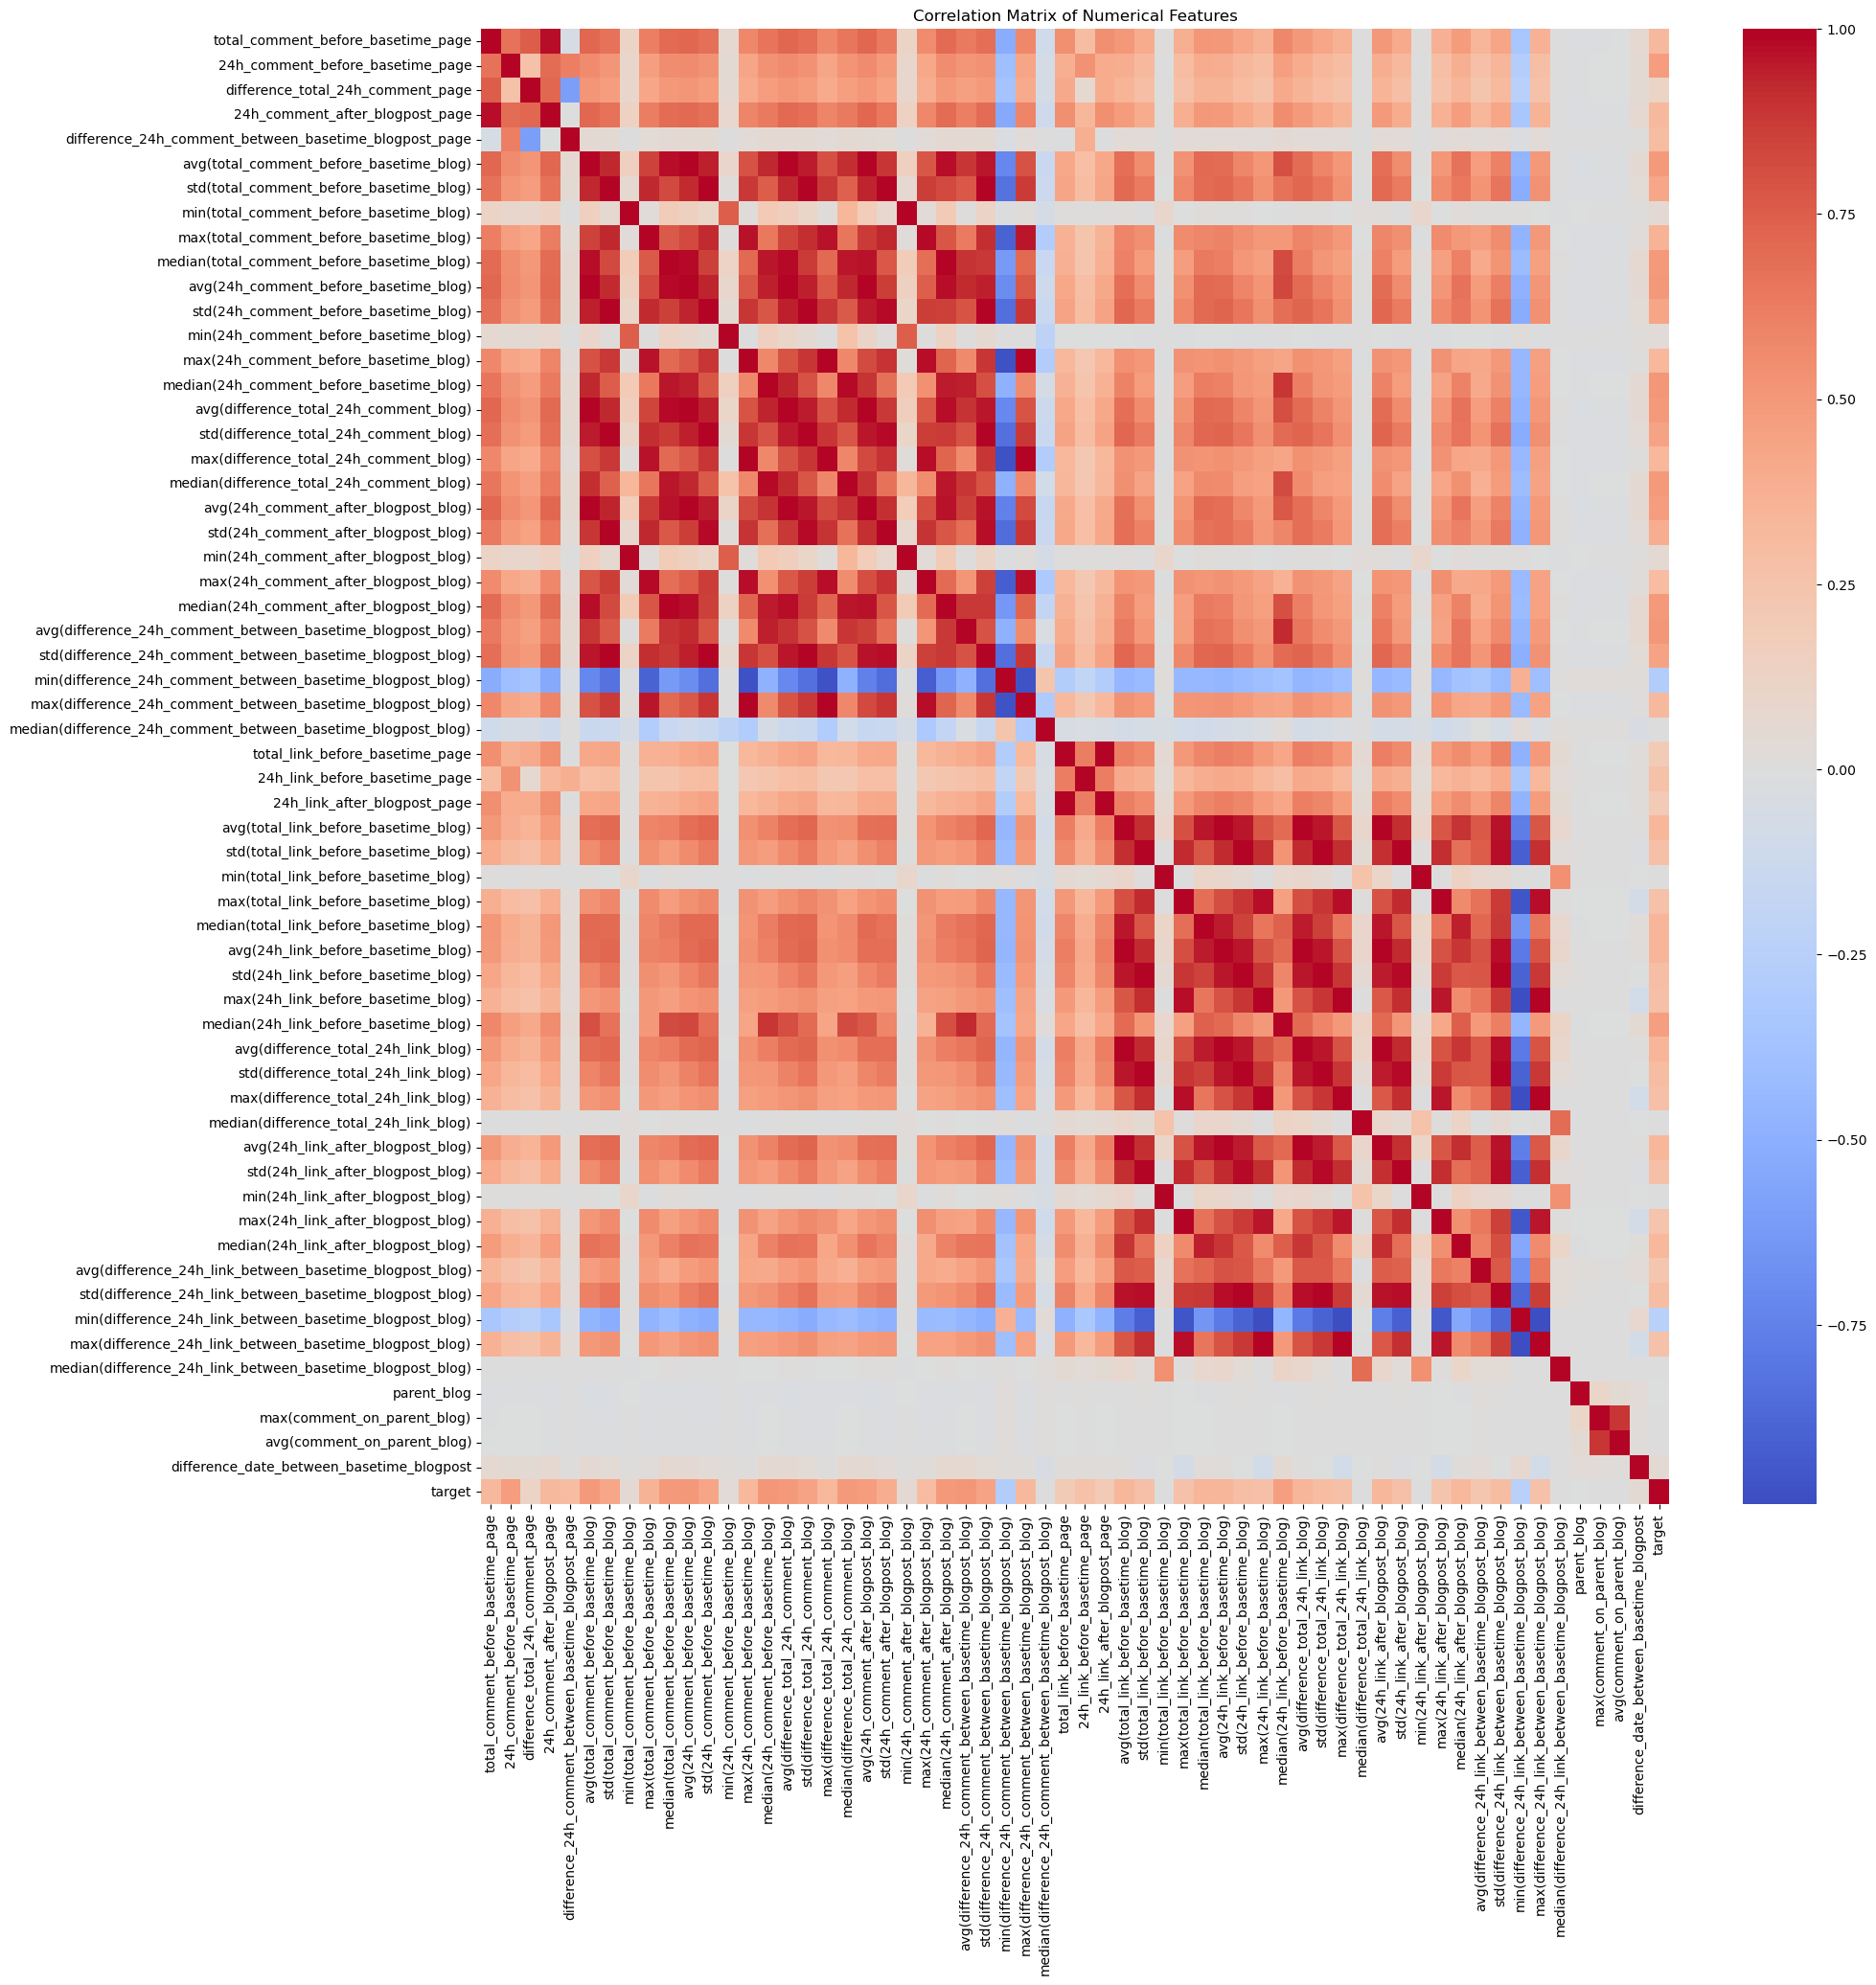

In [26]:
# Compute the correlation matrix for numerical features.
corr_matrix = df_train[numerical_columns].corr()

plt.figure(figsize=(20, 20))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [27]:
target_corr = (
    df_train[numerical_columns]
    .corr()["target"]
    .sort_values(ascending=False)
)

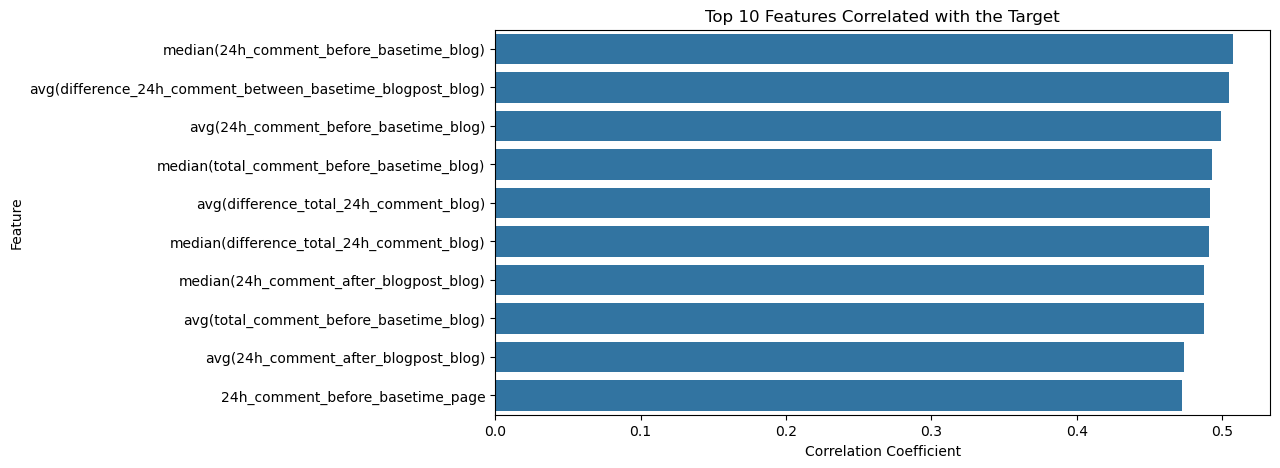

In [28]:
# Top 10 features most correlated with the target variable.
top_corr = target_corr.drop("target").head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top 10 Features Correlated with the Target")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.show()

**Observation**

- Several numerical features exhibit moderate to strong positive correlations with the target variable.
- Features related to historical comment statistics, such as median and average comment counts before the baseline time, show the strongest correlations with the target.
- This suggests that previous user engagement is an important predictor of future comment volume.
- The correlation analysis provides an initial understanding of feature relevance and will be complemented by model-based feature importance in the modeling stage.

### Missing Value Handling

In [29]:
df_train["std(24h_link_after_blogpost_blog)"].describe()

count    48964.000000
mean         0.723443
std          0.928940
min          0.000000
25%          0.000000
50%          0.321003
75%          1.032096
max          4.957952
Name: std(24h_link_after_blogpost_blog), dtype: float64

In [30]:
# Compute the median from the training data.
median_std = df_train["std(24h_link_after_blogpost_blog)"].median()

# Apply the same imputation to both training and testing datasets.
df_train["std(24h_link_after_blogpost_blog)"] = (
    df_train["std(24h_link_after_blogpost_blog)"]
    .fillna(median_std)
)

df_test["std(24h_link_after_blogpost_blog)"] = (
    df_test["std(24h_link_after_blogpost_blog)"]
    .fillna(median_std)
)

In [31]:
remaining_missing = df_train.isnull().sum().sum()

print(f"Remaining missing values: {remaining_missing}")

Remaining missing values: 0


**Observation**

- Only one feature (`std(24h_link_after_blogpost_blog)`) required imputation after preprocessing.
- Because the missing rate was extremely low (124 observations), median imputation was selected as a simple and robust approach.
- The imputation value was computed exclusively from the training dataset and then applied to both the training and testing datasets to maintain a consistent preprocessing pipeline and avoid data leakage.
- No missing values remained after preprocessing.

### Data Validation

Some engineered difference features should follow deterministic relationships between existing columns. We validate these relationships and correct inconsistent values when necessary.

In [32]:
# Validate the engineered difference feature in the training data.
expected_difference_train = (
    df_train["total_comment_before_basetime_page"]
    - df_train["24h_comment_before_basetime_page"]
)

invalid_train_count = (
    df_train["difference_total_24h_comment_page"]
    != expected_difference_train
).sum()

print(f"Invalid values in training data: {invalid_train_count}")

Invalid values in training data: 10489


In [33]:
# Correct the engineered difference feature in the training data.
df_train["difference_total_24h_comment_page"] = expected_difference_train

In [34]:
# Validate that the correction was applied successfully.
remaining_invalid_train = (
    df_train["difference_total_24h_comment_page"]
    != (
        df_train["total_comment_before_basetime_page"]
        - df_train["24h_comment_before_basetime_page"]
    )
).sum()

print(f"Remaining invalid values in training data: {remaining_invalid_train}")

Remaining invalid values in training data: 0


In [35]:
# Apply the same validation and correction to the testing data.
expected_difference_test = (
    df_test["total_comment_before_basetime_page"]
    - df_test["24h_comment_before_basetime_page"]
)

invalid_test_count = (
    df_test["difference_total_24h_comment_page"]
    != expected_difference_test
).sum()

print(f"Invalid values in testing data: {invalid_test_count}")

df_test["difference_total_24h_comment_page"] = expected_difference_test

Invalid values in testing data: 1227


In [36]:
remaining_invalid_test = (
    df_test["difference_total_24h_comment_page"]
    != (
        df_test["total_comment_before_basetime_page"]
        - df_test["24h_comment_before_basetime_page"]
    )
).sum()

print(f"Remaining invalid values in testing data: {remaining_invalid_test}")

Remaining invalid values in testing data: 0


**Observation**

- The engineered feature `difference_total_24h_comment_page` was expected to equal `total_comment_before_basetime_page - 24h_comment_before_basetime_page`.
- This feature did not match the arithmetic difference computed from the source variables for 10,489 training records and 1,227 testing records.
- To ensure internal consistency within this project, the feature was recalculated directly from the source variables.
- After validation and correction, no inconsistencies remained in either the training or testing datasets.

## Model Development

### Feature & Target Split

In [37]:
# Separate features and target.
X = df_train.drop(columns="target")
y = df_train["target"]

X_test = df_test.drop(columns="target")
y_test = df_test["target"]

print(f"Training features: {X.shape}")
print(f"Testing features: {X_test.shape}")

Training features: (49088, 273)
Testing features: (6834, 273)


### Train / Validation Split

In [38]:
random_state = 42

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_state
)

print(f"X_train: {X_train.shape}")
print(f"X_valid: {X_valid.shape}")

X_train: (39270, 273)
X_valid: (9818, 273)


### Evaluation Function

In [39]:
model_results = []

def evaluate_model(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    model_results.append({
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    print(f"{model_name}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")

### Baseline Linear Regression

In [40]:
# Scale features for Linear Regression.
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_valid_scaled = X_valid.copy()
X_test_scaled = X_test.copy()

X_train_scaled[X_train.columns] = scaler.fit_transform(X_train)
X_valid_scaled[X_valid.columns] = scaler.transform(X_valid)
X_test_scaled[X_test.columns] = scaler.transform(X_test)

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_valid_scaled)

evaluate_model("Linear Regression", y_valid, linear_pred)

Linear Regression
RMSE: 31.6762
MAE: 9.3875
R2: 0.3407


### Random Forest Regressor

In [41]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=random_state,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)

evaluate_model("Random Forest Regressor", y_valid, rf_pred)

Random Forest Regressor
RMSE: 28.0556
MAE: 6.4303
R2: 0.4828


### Gradient Boosting Regressor

In [42]:
gb_model = GradientBoostingRegressor(
    random_state=random_state
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_valid)

evaluate_model("Gradient Boosting Regressor", y_valid, gb_pred)

Gradient Boosting Regressor
RMSE: 26.7918
MAE: 6.7311
R2: 0.5283


### Model Comparison

In [43]:
df_model_results = (
    pd.DataFrame(model_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

df_model_results

,Model,RMSE,MAE,R2
0,Gradient Boosting Regressor,26.791840,6.731074,0.528345
1,Random Forest Regressor,28.055583,6.430275,0.482801
2,Linear Regression,31.676244,9.387533,0.340695


### 4.8 Hyperparameter Tuning: Gradient Boosting Regressor
Since Gradient Boosting achieved the best baseline performance, hyperparameter tuning was performed to explore whether additional improvements could be achieved.

In [44]:
gb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [1, 3, 5],
    "subsample": [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=random_state),
    param_distributions=gb_param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=random_state,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Best parameters:", gb_search.best_params_)

Best parameters: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 3, 'learning_rate': 0.03}


In [45]:
gb_tuned_pred = gb_search.best_estimator_.predict(X_valid)

evaluate_model(
    "Tuned Gradient Boosting Regressor",
    y_valid,
    gb_tuned_pred
)

df_model_results = (
    pd.DataFrame(model_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

df_model_results

Tuned Gradient Boosting Regressor
RMSE: 27.3428
MAE: 6.9432
R2: 0.5087


,Model,RMSE,MAE,R2
0,Gradient Boosting Regressor,26.791840,6.731074,0.528345
1,Tuned Gradient Boosting Regressor,27.342792,6.943212,0.508748
2,Random Forest Regressor,28.055583,6.430275,0.482801
3,Linear Regression,31.676244,9.387533,0.340695


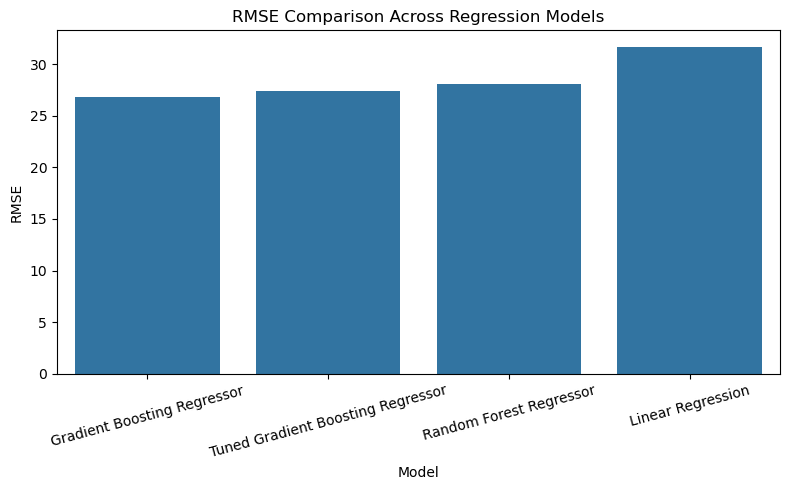

In [46]:
# Compare model performance using RMSE.

rmse_plot = (
    df_model_results
    .sort_values("RMSE")
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=rmse_plot,
    x="Model",
    y="RMSE"
)

plt.xticks(rotation=15)
plt.ylabel("RMSE")
plt.title("RMSE Comparison Across Regression Models")

plt.tight_layout()
plt.show()

**Observation**

- Gradient Boosting achieved the lowest RMSE among the evaluated models.
- Hyperparameter tuning did not improve validation performance, indicating that the default Gradient Boosting configuration already generalized well on this dataset.
- Linear Regression produced the highest prediction error, indicating that the underlying relationship is not purely linear.

### 4.9 Feature Importance
Feature importance was examined using the best-performing Gradient Boosting model to identify which variables contributed most to the prediction.

In [47]:
feature_importance = pd.Series(
    gb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = feature_importance.head(15)

display(top_features)

difference_24h_comment_between_basetime_blogpost_page         0.154015
24h_comment_before_basetime_page                              0.150278
difference_total_24h_comment_page                             0.147135
std(difference_24h_comment_between_basetime_blogpost_blog)    0.131072
std(24h_comment_before_basetime_blog)                         0.081187
std(difference_total_24h_comment_blog)                        0.076886
total_comment_before_basetime_page                            0.052213
avg(difference_24h_comment_between_basetime_blogpost_blog)    0.045814
median(total_comment_before_basetime_blog)                    0.033403
median(24h_comment_after_blogpost_blog)                       0.026468
24h_comment_after_blogpost_page                               0.014413
difference_date_between_basetime_blogpost                     0.011641
median(difference_total_24h_comment_blog)                     0.005449
word_163                                                      0.005280
24h_li

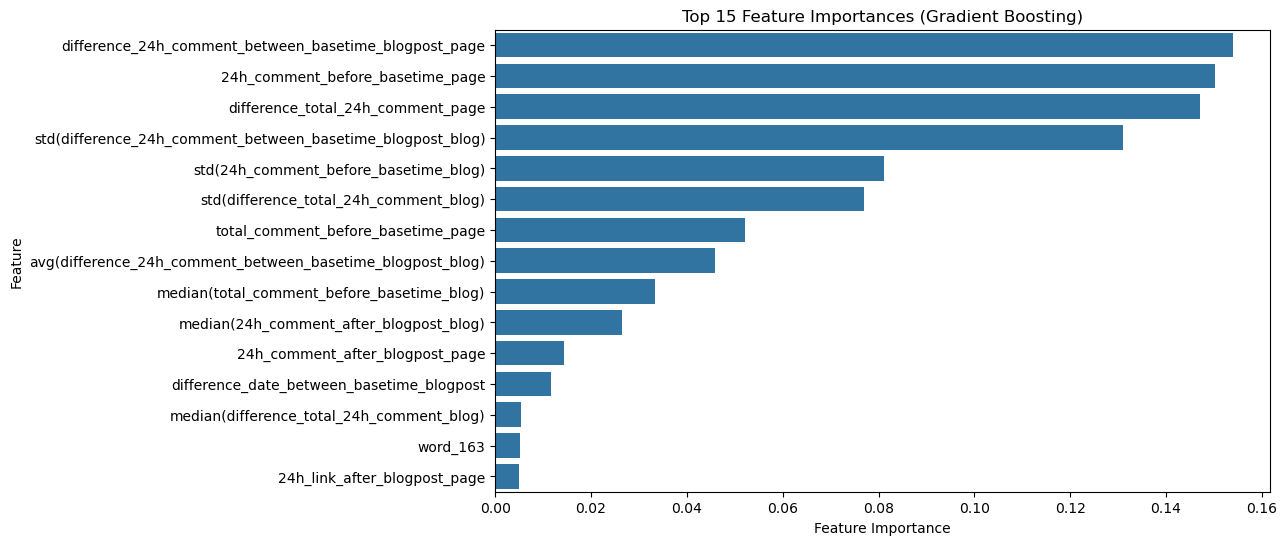

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top 15 Feature Importances (Gradient Boosting)")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

### Prediction vs Actual
The final Gradient Boosting model was evaluated by comparing predicted values against actual values on the validation set.

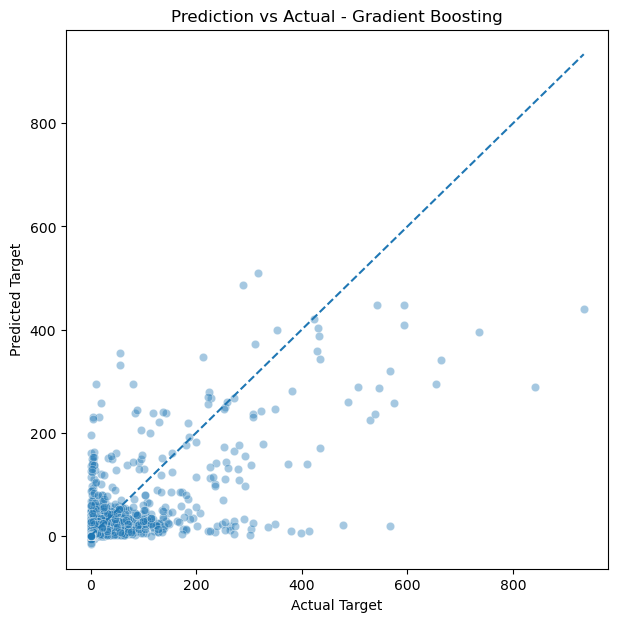

In [49]:
plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=y_valid,
    y=gb_pred,
    alpha=0.4
)

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    linestyle="--"
)

plt.title("Prediction vs Actual - Gradient Boosting")
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")

plt.show()

### Residual Analysis

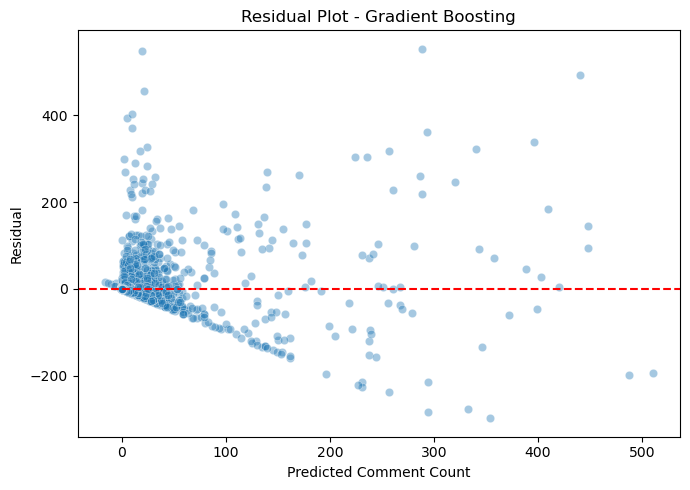

In [50]:
# Calculate residuals of the final model.
residual = residual = y_valid - gb_pred

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=gb_pred,
    y=residual,
    alpha=0.4
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Comment Count")
plt.ylabel("Residual")
plt.title("Residual Plot - Gradient Boosting")

plt.tight_layout()

plt.show()

## Final Insights

- Gradient Boosting achieved the lowest validation RMSE among the evaluated models and was selected as the final model.

- Features describing recent comment activity and changes in engagement over the previous 24 hours were the strongest predictors of future blog comments.

- The prediction plot indicates that the model performs well for typical blog posts but tends to underestimate extremely popular posts with unusually high engagement.

- The residual plot shows that prediction errors increase for larger engagement values, suggesting that highly viral posts remain more difficult to predict.

- Future work could explore additional temporal, textual, or social features to better capture rare high-engagement events and improve prediction accuracy.

### Limitations

- The target distribution is highly right-skewed, making extreme viral posts difficult to predict accurately.
- Only structured numerical and categorical features were used. The actual blog text was not modeled directly.
- More advanced NLP embeddings or temporal sequence models could further improve prediction performance.

## Future Work

Potential improvements include:

- Incorporating text embeddings from blog content instead of summary statistics.
- Evaluating more advanced ensemble models such as XGBoost or LightGBM.
- Applying log transformation to the target variable to better model highly skewed comment distributions.
- Exploring time-series features to capture temporal engagement patterns.
- Incorporating external engagement signals such as author popularity or social media activity.